In [1]:
import sys, os
import numpy as np
import time
import math
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
import matplotlib.pyplot as plt
import cv2
import numpy as np
import color_seg_utils as seg
# %matplotlib widget
%load_ext autoreload
%autoreload 2


In [5]:
data_path = "/home/zfei/codes/data/upi/rs435i_2024-08-22-09-17-13/"
color_img_idx = 0
color_img_path = os.path.join(data_path, f"color_{color_img_idx:06d}.png")
print(color_img_path)


/home/zfei/codes/data/upi/rs435i_2024-08-22-09-17-13/color_000000.png


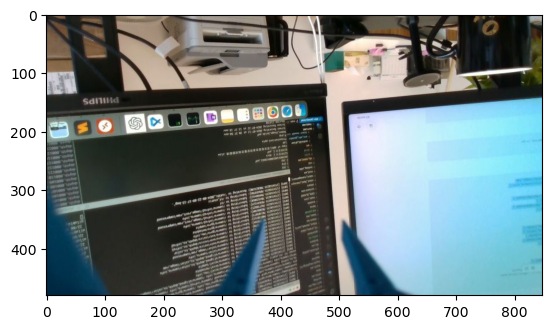

In [7]:
color_img = cv2.cvtColor(cv2.imread(color_img_path), cv2.COLOR_BGR2RGB)
plt.imshow(color_img)

roi_mean [ 15.1509434   61.70849057  90.9990566  101.65283019 224.36698113
  90.9990566 ]
roi_std [23.3804032  26.70292408 29.6116531   1.05071472 37.79033824 29.6116531 ]


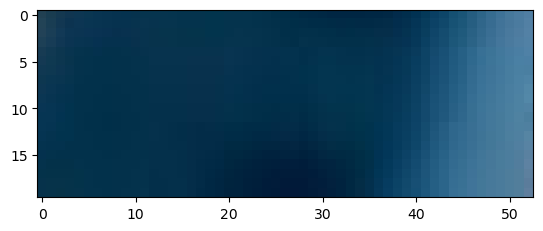

In [17]:
roi = color_img[460:480,300:353, :]
roi_mean, roi_std =  seg.get_center_std(roi)
print("roi_mean", roi_mean)
print("roi_std", roi_std)
plt.imshow(roi)

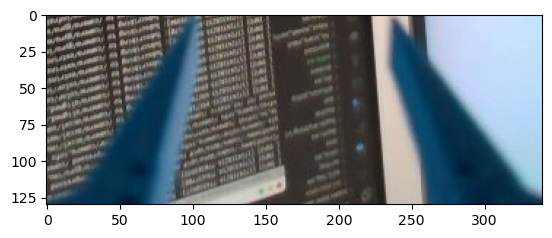

In [32]:
gripper_part = color_img[350:480, 270:610, :]
plt.imshow(gripper_part)

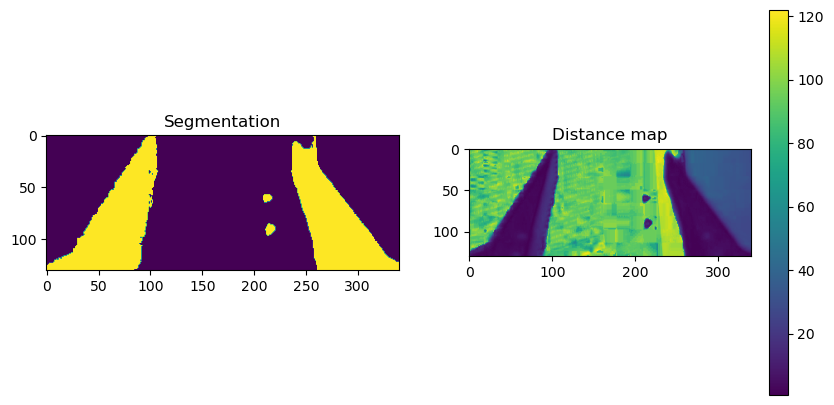

In [33]:
# Load image
threshold = 20
segmentation, distance_map = seg.segment(gripper_part, roi_mean, roi_std, threshold, var_weighting=False)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(segmentation)
axs[0].set_title("Segmentation")
axs[1].imshow(distance_map)
axs[1].set_title("Distance map")
# add colorbar
plt.colorbar(axs[1].imshow(distance_map), ax=axs[1])